In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn import preprocessing
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn import metrics
from sklearn.feature_extraction import text 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,make_scorer, f1_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import re 
from rapidfuzz import process, fuzz


In [2]:
df_admits = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\diagnoses_icd.csv.gz', compression='gzip')
df_transfers = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'\\gstt.local\shared\HealthInformatics\Analysis\Saaqib\MIMIC-IV\emar.csv.gz', compression='gzip')

In [2]:
df_admits = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\admissions.csv.gz', compression='gzip')
df_pat = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\patients.csv.gz', compression='gzip')
df_icd_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_procedures.csv.gz', compression='gzip')
df_icd_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\d_icd_diagnoses.csv.gz', compression='gzip')
df_proc = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\procedures_icd.csv.gz', compression='gzip')
df_diagnosis = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\diagnoses_icd.csv.gz', compression='gzip')
#df_transfers = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\transfers.csv.gz', compression='gzip')
df_medi = pd.read_csv(r'C:\Users\Saaqib\Documents\Projects\MIMIC_IV\emar.csv.gz', compression='gzip')

In [3]:
pd.set_option('max_colwidth', None)

In [40]:
#print(df_admits.head(10))
#print(df_diagnosis.head(10))
#print(df_icd_proc.head(10))
#print(df_icd_diagnosis.head(10))
df_pat.head(10)

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13
5,10000102,F,27,2136,2008 - 2010,NaN
6,10000108,M,25,2163,2014 - 2016,NaN
7,10000115,M,24,2154,2017 - 2019,NaN
8,10000117,F,48,2174,2008 - 2010,NaN
9,10000161,M,60,2163,2020 - 2022,NaN


In [209]:
# Data Checks

#df_admits.isna().any() # check which columns have NaN
df_admits.loc[:,df_admits.isna().any()]
#df_admits[df_admits['admission_location'] == '']
#pd.reset_option('display.max_rows')


,deathtime,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,edregtime,edouttime
0,NaN,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,2180-05-06 19:17:00,2180-05-06 23:30:00
1,NaN,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-06-26 15:54:00,2180-06-26 21:31:00
2,NaN,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,2180-08-05 20:58:00,2180-08-06 01:44:00
3,NaN,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,2180-07-23 05:54:00,2180-07-23 14:00:00
4,NaN,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,2160-03-03 21:55:00,2160-03-04 06:26:00
...,...,...,...,...,...,...,...,...,...
546023,NaN,P13JMH,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2149-01-08 09:11:00,2149-01-08 18:12:00
546024,NaN,P38XL8,PHYSICIAN REFERRAL,HOME HEALTH CARE,Medicaid,English,SINGLE,2147-07-17 17:18:00,2147-07-18 17:34:00
546025,2164-09-17 13:42:00,P33612,EMERGENCY ROOM,DIED,Private,English,WIDOWED,2164-09-10 11:09:00,2164-09-10 14:46:00
546026,NaN,P036NA,EMERGENCY ROOM,HOME,Private,English,WIDOWED,2164-07-24 21:16:00,2164-07-25 01:20:00


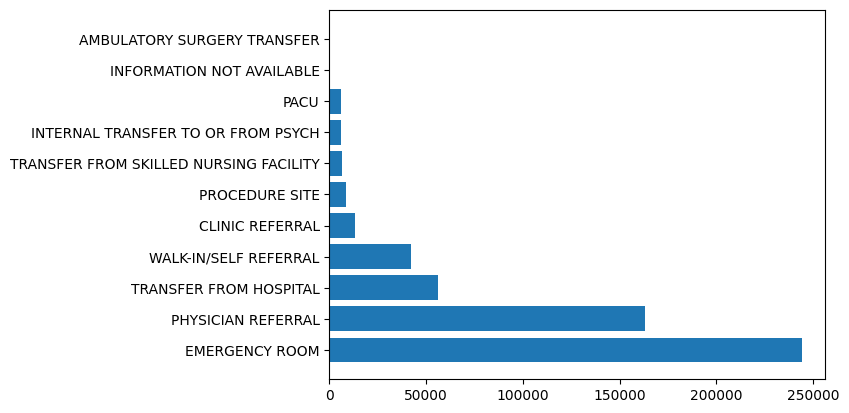

In [210]:
plt.barh(df_admits['admission_location'].value_counts().index,df_admits.admission_location.value_counts().values)
plt.show() # to check for missing values 

In [4]:
# Join diagnosis, admissions and procs
df_admit_icd = pd.merge(df_admits,df_diagnosis,how = 'left', on = 'hadm_id')
df_admit_diagnosis = pd.merge(df_admit_icd,df_icd_diagnosis,how = 'left', on = 'icd_code')
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_icd_proc,how = 'left', on = 'icd_code')
df_admit_diagnosis.drop(columns= ['subject_id_y'], inplace = True)
df_admit_diagnosis.rename(columns={'long_title_x': 'icd_diagnosis_name','long_title_y':'proc_name','subject_id_x':'subject_id'}, inplace=True)
df_admit_diagnosis = pd.merge(df_admit_diagnosis,df_pat[['subject_id', 'anchor_age','gender']],how = 'left', on = 'subject_id')

In [5]:
# Replace all NaN 
df_admit_diagnosis['icd_diagnosis_name'] = df_admit_diagnosis['icd_diagnosis_name'].fillna('No Diagnosis')
df_admit_diagnosis['proc_name'] = df_admit_diagnosis['proc_name'].fillna('No Procedure')
df_admit_diagnosis['icd_code'] = df_admit_diagnosis['icd_code'].fillna('No ICD Code')
df_admit_diagnosis[df_admit_diagnosis['proc_name'].isna()]

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender


In [6]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,hospital_expire_flag,seq_num,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,1.0,5723,9.0,9.0,Portal hypertension,NaN,No Procedure,52,F
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,2.0,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,3.0,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,4.0,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic coma,NaN,No Procedure,52,F
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,0,5.0,496,9.0,9.0,"Chronic airway obstruction, not elsewhere classified",9.0,Excision of anus,52,F


In [19]:
print("\n".join(map(str, df_admit_diagnosis.icd_diagnosis_name.unique())))

Portal hypertension
Other ascites
Cirrhosis of liver without mention of alcohol
Unspecified viral hepatitis C without hepatic coma
Chronic airway obstruction, not elsewhere classified
Bipolar disorder, unspecified
Posttraumatic stress disorder
Personal history of tobacco use
Unspecified viral hepatitis C with hepatic coma
Thrombocytopenia, unspecified
Hyposmolality and/or hyponatremia
Asymptomatic human immunodeficiency virus [HIV] infection status
Tobacco use disorder
Chronic hepatitis C without mention of hepatic coma
Other dependence on machines, supplemental oxygen
Person on outside of car injured in collision with other nonmotor vehicle in nontraffic accident
Hyperpotassemia
Diarrhea
Other iatrogenic hypotension
Chronic hepatitis C with hepatic coma
Cachexia
Do not resuscitate status
Alcohol abuse, unspecified
Neurocognitive disorder with Lewy bodies
Dementia in other diseases classified elsewhere, unspecified severity, without behavioral disturbance, psychotic disturbance, mood d

Ensure normalisation of icd_diagnosis_name and proc_name

In [7]:
my_stop_words = ['term','episode', 'face', 'facial','mouth','home','legs','pain'
                 ,'procedure','procedures','diagnosis','weight','adult','child','unspecified','primary','secondary','other','long'
                 ,'system', 'due', 'related', 'associated', 'organ', 'tissue', 'area', 'region', 'tract'
                 ,'side', 'lobe', 'part', 'left', 'right', 'bilateral', 'upper', 'lower', 'anterior','encounter'
                 ,'posterior', 'icd', 'code','type', 'specified', 'classification', 'negative','positive'
                 ,'history', 'present', 'past','recent', 'new', 'old','accessory','adhesive','body', 'blood'
                 ,'classified','unclassified','cause','causing','reaction','status','current','complication'
                 ,'do','not','classified','elsewhere','severity','without','history','personal','cause','initial']
combined_stop_words = list(text.ENGLISH_STOP_WORDS.union(my_stop_words))


def normalise_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)      # remove punctuation
    text = re.sub(r'\d+', '', text)          # remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    tokens = text.split()                    # Tokenize
    filtered_tokens = [word for word in tokens if word not in combined_stop_words]  # Remove stop words
    return ' '.join(filtered_tokens)

In [22]:
# Testing normalisation with subset
df_admit_diagnosis_subset = df_admit_diagnosis.loc[1:10000,:]
df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)

C:\Users\smahmood\AppData\Local\Temp\ipykernel_20160\1531015921.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_clean'] = df_admit_diagnosis_subset['icd_diagnosis_name'].apply(normalise_text)


In [23]:
unique_diagnoses = df_admit_diagnosis_subset['diagnosis_clean'].dropna().unique()

In [8]:
def standardise_similar_entries(unique_values, threshold=80):
    standardisation_map = {}
    value_list = list(unique_values)
    
    for i, current_value in enumerate(value_list):
        if current_value is None or current_value == '':
            continue  # skip empty
        
        if current_value in standardisation_map:
            continue  # already mapped
        
        # Create a list excluding current_value
        others = value_list[:i] + value_list[i+1:]
        
        match = process.extractOne(
            current_value,
            others,
            processor=None,
            scorer=fuzz.token_sort_ratio,
            score_cutoff=threshold
        )
        
        if match:
            matched_value = match[0]
            standardisation_map[matched_value] = current_value
            standardisation_map[current_value] = current_value
        else:
            # map self if no close match found
            standardisation_map[current_value] = current_value
            
    return standardisation_map

In [25]:
standardised_map_subset = standardise_similar_entries(unique_diagnoses)

In [26]:
df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])

C:\Users\smahmood\AppData\Local\Temp\ipykernel_20160\3282736867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_admit_diagnosis_subset['diagnosis_name'] = df_admit_diagnosis_subset['diagnosis_clean'].map(standardised_map_subset).fillna(df_admit_diagnosis_subset['icd_diagnosis_name'])


In [27]:
df_admit_diagnosis_subset.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_code,icd_version_x,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,diagnosis_name
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,78959,9.0,9.0,Other ascites,NaN,No Procedure,52,F,ascites,ascites
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,5715,9.0,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,cirrhosis liver mention alcohol
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,07070,9.0,9.0,Unspecified viral hepatitis C without hepatic ...,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,viral hepatitis c hepatic coma
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,496,9.0,9.0,"Chronic airway obstruction, not elsewhere clas...",9.0,Excision of anus,52,F,chronic airway obstruction,chronic airway obstruction
5,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,29680,9.0,9.0,"Bipolar disorder, unspecified",NaN,No Procedure,52,F,bipolar disorder,bipolar disorder


In [9]:
## Actual 
df_admit_diagnosis['diagnosis_clean'] = df_admit_diagnosis['icd_diagnosis_name'].apply(normalise_text)
df_admit_diagnosis['procedure_clean'] = df_admit_diagnosis['proc_name'].apply(normalise_text)

unique_diagnoses = df_admit_diagnosis['diagnosis_clean'].dropna().unique()
unique_proc = df_admit_diagnosis['procedure_clean'].dropna().unique()

In [10]:
# Map the cleaned diagnosis to the standardised form
standardised_map_diagnosis = standardise_similar_entries(unique_diagnoses)
standardised_map_proc = standardise_similar_entries(unique_proc)

In [11]:
df_admit_diagnosis['diagnosis_name'] = df_admit_diagnosis['diagnosis_clean'].map(standardised_map_diagnosis).fillna(df_admit_diagnosis['icd_diagnosis_name'])
df_admit_diagnosis['procedure_name'] = df_admit_diagnosis['procedure_clean'].map(standardised_map_proc).fillna(df_admit_diagnosis['proc_name'])

In [12]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,...,icd_version_y,icd_diagnosis_name,icd_version,proc_name,anchor_age,gender,diagnosis_clean,procedure_clean,diagnosis_name,procedure_name
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Portal hypertension,NaN,No Procedure,52,F,portal hypertension,,portal hypertension,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Other ascites,NaN,No Procedure,52,F,ascites,,ascites,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Cirrhosis of liver without mention of alcohol,NaN,No Procedure,52,F,cirrhosis liver mention alcohol,,cirrhosis liver mention alcohol,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,Unspecified viral hepatitis C without hepatic coma,NaN,No Procedure,52,F,viral hepatitis c hepatic coma,,viral hepatitis c hepatic coma,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,...,9.0,"Chronic airway obstruction, not elsewhere classified",9.0,Excision of anus,52,F,chronic airway obstruction,excision anus,chronic airway obstruction,excision anus


In [52]:
print("\n".join(map(str, df_admit_diagnosis.diagnosis_name.unique())))

portal hypertension
ascites
cirrhosis liver mention alcohol
viral hepatitis c hepatic coma
chronic airway obstruction
bipolar ii disorder
posttraumatic stress disorder chronic
tobacco use
thrombocytopenia
hyposmolality andor hyponatremia
asymptomatic human immunodeficiency virus hiv infection
tobacco use disorder
chronic hepatitis c mention hepatic coma
dependence machines supplemental oxygen
person outside car injured collision nonmotor vehicle nontraffic accident
hyperpotassemia
diarrhea
iatrogenic hypotension
cachexia
resuscitate
alcohol abuse
neurocognitive disorder lewy bodies
dementia diseases behavioral disturbance psychotic disturbance mood disturbance anxiety
visual hallucinations
repeated falls
hyperlipidemia
malignant neoplasm prostate
altered mental
parkinsons disease
edema
cellulitis abscess oral soft tissues
dental caries
dysphagia
symptoms signs involving circulatory respiratory systems
angiodysplasia stomach duodenum bleeding
gastroesophageal reflux disease esophagitis


In [13]:
diagnosis_counts = df_admit_diagnosis.diagnosis_name.value_counts()
proc_counts = df_admit_diagnosis.procedure_name.value_counts()

# Get the top 200 ICD codes by frequency
top_200_diagnosis = df_admit_diagnosis['diagnosis_name'].value_counts().nlargest(201).index
top_200_proc = df_admit_diagnosis['procedure_name'].value_counts().nlargest(201).index

# Map ICD codes — keep top 200, replace others with 'Other Code'
df_admit_diagnosis['diagnosis_converted'] = df_admit_diagnosis['diagnosis_name'].apply(
    lambda x: str(x) if x in top_200_diagnosis else 'Other Diagnosis'
)
df_admit_diagnosis['procedure_converted'] = df_admit_diagnosis['procedure_name'].apply(
    lambda x: str(x) if x in top_200_proc else 'Other Procedure'
)

df_admit_diagnosis.drop(columns = ['icd_version_y','icd_version_x','edregtime','edouttime','deathtime','admit_provider_id','hospital_expire_flag','icd_diagnosis_name','proc_name',
                                         'seq_num','icd_code','language','icd_version','diagnosis_clean','diagnosis_name','procedure_clean','procedure_name'],inplace = True)

In [14]:
df_admit_diagnosis.head()

,subject_id,hadm_id,admittime,dischtime,admission_type,admission_location,discharge_location,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,portal hypertension,No Procedure
1,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,ascites,No Procedure
2,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,Other Diagnosis,No Procedure
3,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,viral hepatitis c hepatic coma,No Procedure
4,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,WIDOWED,WHITE,52,F,chronic airway obstruction,excision anus


In [55]:
pd.set_option('display.max_rows', 10)
print(df_admit_diagnosis.procedure_converted.value_counts().head(10000))

procedure_converted
No Procedure                                                  5918460
diagnostic lymphatic structures                                106026
biopsy structure                                                67293
temporary tracheostomy                                          36349
repair urethra                                                  29136
                                                               ...   
prophylactic vaccination arthropodborne viral encephalitis        220
endoscopic dilation pylorus                                       216
miscellaneous                                                     215
permanent tracheostomy                                            212
anastomosis bypass ureter                                         210
Name: count, Length: 202, dtype: int64


In [ ]:
# Group first to reduce data size
df_admit_diagnosis_grouped = df_admit_diagnosis.groupby(['hadm_id', 'subject_id']).agg({  
     'admission_type':'first',
     'admission_location': 'first',
     'discharge_location':'first',
     'admittime':'first',
     'dischtime':'first',
     'insurance':'first',
     'marital_status': 'first',
     'race':'first',
     'anchor_age': 'first',
     'gender': lambda x: set(x),
     'diagnosis_converted': lambda x: set(x),
     'procedure_converted': lambda x: set(x),
     }).reset_index()
df_admit_diagnosis_grouped.head(5)  

,hadm_id,subject_id,admission_type,admission_location,discharge_location,admittime,dischtime,insurance,marital_status,race,anchor_age,gender,diagnosis_converted,procedure_converted
0,20000019,10467237,EW EMER.,EMERGENCY ROOM,HOME,2159-03-20 21:08:00,2159-03-23 16:54:00,Medicaid,SINGLE,HISPANIC/LATINO - GUATEMALAN,76,{F},"{hyperlipidemia, malignant essential hypertension, acute kidney failure, hyposmolality andor hyponatremia, asthma, Other Diagnosis, bandemia, diabetes mellitus mention ii stated uncontrolled}","{repair urethra, suture laceration palate, biopsy structure, No Procedure, diagnostic lymphatic structures}"
1,20000024,16925328,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,2151-05-25 21:44:00,2151-05-26 18:36:00,Medicare,SINGLE,WHITE,84,{F},"{Other Diagnosis, osteoporosis pathological fracture, falling, malignant essential hypertension}",{No Procedure}
2,20000034,19430048,DIRECT OBSERVATION,PHYSICIAN REFERRAL,None,2174-05-22 19:13:00,2174-05-24 17:27:00,Medicare,SINGLE,BLACK/CARIBBEAN ISLAND,72,{M},"{drug chemical induced diabetes mellitus diabetic chronic kidney disease, severe proteincalorie malnutrition, hypertensive chronic kidney disease stage stage chronic kidney disease chronic kidney disease, protein deficiency anemia, malignant neoplasm main bronchus, use insulin, transient ischemic attack tia cerebral infarction residual deficits, hypoosmolality hyponatremia, mass index, insomni...","{physical rehabilitation diagnostic audiology rehabilitation hearing treatment, No Procedure}"
3,20000041,18910522,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,SKILLED NURSING FACILITY,2143-09-03 07:15:00,2143-09-06 13:50:00,Private,SINGLE,WHITE,62,{F},"{obesity, hyperlipidemia, malignant essential hypertension, bariatric surgery, mass index, Other Diagnosis, esophageal reflux, venous thrombosis nec}","{diagnostic lymphatic structures, biopsy structure, No Procedure}"
4,20000045,13413708,OBSERVATION ADMIT,WALK-IN/SELF REFERRAL,HOME HEALTH CARE,2138-05-21 16:25:00,2138-05-29 02:05:00,Private,DIVORCED,WHITE,51,{F},"{urinary infection site, nicotine dependence, escherichia coli e coli diseases, covid, Other Diagnosis, fall stairs ladders water transport injuring person, disorders phosphorus metabolism, sepsis organism}",{No Procedure}


In [93]:
# Assign admission ranks throughout time
# Readmission is within 30 days of discharge and next admission so insert flag

df_admit_diagnosis_grouped['admittime'] = pd.to_datetime(df_admit_diagnosis_grouped['admittime'])
df_admit_diagnosis_grouped['dischtime'] = pd.to_datetime(df_admit_diagnosis_grouped['dischtime'])

df_admit_diagnosis_grouped['admission_rank'] = df_admit_diagnosis_grouped.groupby('subject_id')['admittime'].rank(method='dense', ascending=True)
df_admit_diagnosis_grouped.sort_values(by = ['admission_rank'],ascending= True, inplace= True)
# Get next admission's out time for each patient
df_admit_diagnosis_grouped['last_dischtime'] = df_admit_diagnosis_grouped.groupby('subject_id')['dischtime'].shift(1)

# Calculate days until next visit
df_admit_diagnosis_grouped['days_from_last'] = (df_admit_diagnosis_grouped['admittime'] - df_admit_diagnosis_grouped['last_dischtime']).dt.days

# Create readmission flag (1 if last visit is within 30 days, else 0)
df_admit_diagnosis_grouped['readmission'] = df_admit_diagnosis_grouped['days_from_last'].apply(lambda x: 1 if pd.notnull(x) and x <= 30 and x >= 0 else 0)

#df_admit_diagnosis_grouped[df_admit_diagnosis_grouped['subject_id'] == 10000032]

In [ ]:
# one hot encode the text columns
df_admit_diagnosis_encoded = df_admit_diagnosis_grouped.drop(columns= ['admittime','dischtime','last_dischtime','days_from_last', 
                                                                       'admission_rank']) # drop irrelevant cols

cols_to_encode = ['admission_type','admission_location','discharge_location','insurance','race','marital_status']
df_admit_diagnosis_encoded = pd.get_dummies(df_admit_diagnosis_encoded, columns=cols_to_encode, drop_first=True,dtype=int)
df_admit_diagnosis_encoded[df_admit_diagnosis_encoded['subject_id'] == 10000032]


,hadm_id,subject_id,anchor_age,gender,diagnosis_converted,procedure_converted,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED
141961,22595853,10000032,52,{F},"{ascites, viral hepatitis c hepatic coma, portal hypertension, chronic airway obstruction, bipolar ii disorder, tobacco use, Other Diagnosis, posttraumatic stress disorder chronic}","{excision anus, No Procedure}",0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
155119,22841357,10000032,52,{F},"{viral hepatitis c hepatic coma, ascites, chronic airway obstruction, thrombocytopenia, hyposmolality andor hyponatremia, Other Diagnosis, tobacco use disorder}","{suture laceration palate, excision anus, No Procedure}",0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
495453,29079034,10000032,52,{F},"{ascites, chronic airway obstruction, dependence machines supplemental oxygen, hyperpotassemia, hyposmolality andor hyponatremia, bipolar ii disorder, Other Diagnosis, resuscitate, chronic hepatitis c mention hepatic coma, tobacco use disorder}","{operation bone injury phalanges hand, suture laceration palate, excision anus, No Procedure}",1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1
313493,25742920,10000032,52,{F},"{ascites, diarrhea, chronic airway obstruction, dependence machines supplemental oxygen, hyperpotassemia, hyposmolality andor hyponatremia, Other Diagnosis, chronic hepatitis c mention hepatic coma, tobacco use disorder}","{suture laceration palate, excision anus, No Procedure}",1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1


In [96]:
for col in ['diagnosis_converted', 'procedure_converted','gender']:
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(df_admit_diagnosis_encoded[col])
    df_encoded = pd.DataFrame.sparse.from_spmatrix(
        X,
        index=df_admit_diagnosis_encoded['hadm_id'],
        columns=[f"{c}" for c in mlb.classes_]
    )
    df_admit_diagnosis_encoded = df_admit_diagnosis_encoded.merge(
        df_encoded, left_on='hadm_id', right_index=True, how='left'
    )

In [97]:
pd.set_option('display.max_columns', None)
df_admit_diagnosis_encoded.head()

,hadm_id,subject_id,anchor_age,gender,diagnosis_converted,procedure_converted,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs,alcohol abuse,alcoholic cirrhosis liver ascites,anemia chronic kidney disease,antineoplastic immunotherapy,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,atypical depressive disorder,bacteremia,bandemia,bariatric surgery,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,bloodsampling abnormal patient later mention misadventure time,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess leg foot,cellulitis limb,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary embolism,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,corridor hospital place occurrence external,covid,cystic kidney disease,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,diabetes mellitus circulatory complications,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitus 

In [98]:
df_admit_diagnosis_encoded.drop(columns=['diagnosis_converted','procedure_converted','gender'], inplace= True)

In [99]:
print("Length of Original Data: ",len(df_admit_diagnosis_encoded))
print("Length of Data After MLB: ",len(df_admit_diagnosis_encoded))

Length of Original Data:  546028
Length of Data After MLB:  546028


Encode Medication Data

In [22]:
df_medi.drop(columns = ['enter_provider_id','charttime','scheduletime','storetime','emar_id','emar_seq','poe_id','pharmacy_id','enter_provider_id'
                        ,'charttime','scheduletime','storetime'], inplace= True)
df_medi['medication'] = df_medi['medication'].fillna('No Medication')
df_medi.head(5)

,subject_id,hadm_id,medication,event_txt
0,10000032,22595853.0,Heparin,Administered
1,10000032,22595853.0,Raltegravir,Administered
2,10000032,22595853.0,Sodium Chloride 0.9% Flush,Flushed
3,10000032,22595853.0,Nicotine Patch,Not Applied
4,10000032,22595853.0,Furosemide,Not Given


In [23]:
# Define grouping rules for usage
administered = [
    'Administered', 'Partial Administered', 'Applied',
    'Confirmed', 'Started', 'Administered in Other Location',
    'Started in Other Location', 'Administered Bolus from IV Drip',
    'Applied in Other Location', 'Removed Existing / Applied New',
    'Removed Existing / Applied New in Other Location',
    'Restarted', 'Restarted in Other Location'
]

not_administered = [
    'Not Applied', 'Not Given', 'Not Flushed', 'Hold Dose', 'Removed',
    'Not Confirmed', 'Not Started', 'Not Assessed', 'Not Removed',
    'Not Stopped', 'Not Read', 'Not Given per Sliding Scale',
    'Not Stopped per Sliding Scale', 'Not Started per Sliding Scale',
    'Not Given per Sliding Scale in Other Location', 'Read', 'Read in Other Location', 'Stopped', 'Stopped As Directed',
    'Stopped - Unscheduled', 'Stopped - Unscheduled in Other Location',
    'Rate Change', 'Rate Change in Other Location','Removed in Other Location',
    'Confirmed in Other Location'

]

delayed = [s for s in df_medi['event_txt'].dropna().unique() if s.startswith('Delayed')]

other = [
    'Flushed', 'Flushed in Other Location', 'Assessed',
    'Assessed in Other Location', 'Infusion Reconciliation',
    'Infusion Reconciliation Not Done', 'Pain score re-assessment',
    'Pain score re-assess not done', 'Documented in O.R. Holding',
    'TPN Rate Not Changed', ' in Other Location', 'Partial ',
]

In [24]:
# Make sure event lists are sets for faster lookup
administered_set = set(administered)
not_administered_set = set(not_administered)
delayed_set = set(delayed)

# Initialize with 'Other'
df_medi['usage'] = 'Other'

# Apply conditions using boolean indexing
mask_admin = df_medi['event_txt'].isin(administered_set) & (df_medi['medication'] != 'No Medication')
mask_not_admin = df_medi['event_txt'].isin(not_administered_set)
mask_delayed = df_medi['event_txt'].isin(delayed_set)

df_medi.loc[mask_admin, 'usage'] = 'Administered'
df_medi.loc[mask_not_admin, 'usage'] = 'Not Administered'
df_medi.loc[mask_delayed, 'usage'] = 'Delayed'

# Filter to only include 'Administered'
df_medi = df_medi[df_medi['usage'] == 'Administered']
df_medi['medication'] = df_medi['medication'].str.lower()

In [25]:
df_medi[df_medi['usage']=='Administered'] # only administered values will have an affect

,subject_id,hadm_id,medication,event_txt,usage
0,10000032,22595853.0,heparin,Administered,Administered
1,10000032,22595853.0,raltegravir,Administered,Administered
7,10000032,22595853.0,albuterol inhaler,Administered,Administered
8,10000032,22595853.0,furosemide,Administered,Administered
9,10000032,22595853.0,spironolactone,Administered,Administered
...,...,...,...,...,...
42808584,19999828,29734428.0,lorazepam,Administered,Administered
42808585,19999828,29734428.0,insulin,Administered,Administered
42808588,19999828,NaN,morphine sulfate,Administered,Administered
42808590,19999828,NaN,ondansetron,Administered,Administered


In [26]:
top_100_meds = df_medi['medication'].value_counts().nlargest(201).index

df_medi['medication_grouped'] = df_medi['medication'].apply(
    lambda x: str(x) if x in top_100_meds else 'Other Medication'
)

In [208]:
# Group first to reduce data size
df_medi.drop(columns=['medication','event_txt','usage'],inplace=True)

df_medi_grouped = df_medi.groupby(['hadm_id', 'subject_id']).agg({  
     'medication_grouped': lambda x: set(x),
     }).reset_index()
df_medi_grouped.head(5)  

KeyError: "['medication', 'event_txt', 'usage'] not found in axis"

In [28]:
mlb = MultiLabelBinarizer(sparse_output=True)
X = mlb.fit_transform(df_medi_grouped['medication_grouped'])

df_medi_encoded = pd.DataFrame.sparse.from_spmatrix(
    X,
    index=df_medi_grouped['hadm_id'],
    columns=mlb.classes_
)

In [29]:
df_medi_encoded.drop(columns=['Other Medication'], inplace=True)

In [100]:
df_full_dataset = pd.merge(
    df_admit_diagnosis_encoded,
    df_medi_encoded,
    how='left',
    on='hadm_id'
)
df_full_dataset.fillna(0, inplace=True)

In [101]:
df_full_dataset

,hadm_id,subject_id,anchor_age,readmission,admission_type_DIRECT EMER.,admission_type_DIRECT OBSERVATION,admission_type_ELECTIVE,admission_type_EU OBSERVATION,admission_type_EW EMER.,admission_type_OBSERVATION ADMIT,admission_type_SURGICAL SAME DAY ADMISSION,admission_type_URGENT,admission_location_CLINIC REFERRAL,admission_location_EMERGENCY ROOM,admission_location_INFORMATION NOT AVAILABLE,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,admission_location_PACU,admission_location_PHYSICIAN REFERRAL,admission_location_PROCEDURE SITE,admission_location_TRANSFER FROM HOSPITAL,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,admission_location_WALK-IN/SELF REFERRAL,discharge_location_AGAINST ADVICE,discharge_location_ASSISTED LIVING,discharge_location_CHRONIC/LONG TERM ACUTE CARE,discharge_location_DIED,discharge_location_HEALTHCARE FACILITY,discharge_location_HOME,discharge_location_HOME HEALTH CARE,discharge_location_HOSPICE,discharge_location_OTHER FACILITY,discharge_location_PSYCH FACILITY,discharge_location_REHAB,discharge_location_SKILLED NURSING FACILITY,insurance_Medicare,insurance_No charge,insurance_Other,insurance_Private,race_ASIAN,race_ASIAN - ASIAN INDIAN,race_ASIAN - CHINESE,race_ASIAN - KOREAN,race_ASIAN - SOUTH EAST ASIAN,race_BLACK/AFRICAN,race_BLACK/AFRICAN AMERICAN,race_BLACK/CAPE VERDEAN,race_BLACK/CARIBBEAN ISLAND,race_HISPANIC OR LATINO,race_HISPANIC/LATINO - CENTRAL AMERICAN,race_HISPANIC/LATINO - COLUMBIAN,race_HISPANIC/LATINO - CUBAN,race_HISPANIC/LATINO - DOMINICAN,race_HISPANIC/LATINO - GUATEMALAN,race_HISPANIC/LATINO - HONDURAN,race_HISPANIC/LATINO - MEXICAN,race_HISPANIC/LATINO - PUERTO RICAN,race_HISPANIC/LATINO - SALVADORAN,race_MULTIPLE RACE/ETHNICITY,race_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,race_OTHER,race_PATIENT DECLINED TO ANSWER,race_PORTUGUESE,race_SOUTH AMERICAN,race_UNABLE TO OBTAIN,race_UNKNOWN,race_WHITE,race_WHITE - BRAZILIAN,race_WHITE - EASTERN EUROPEAN,race_WHITE - OTHER EUROPEAN,race_WHITE - RUSSIAN,marital_status_MARRIED,marital_status_SINGLE,marital_status_WIDOWED,Other Diagnosis,abnormal coagulation profile,accident,accidents occurring place,accidents occurring residential institution,acidosis,acquired hypothyroidism,acute chronic diastolic congestive heart failure,acute chronic diastolic heart failure,acute chronic systolic congestive heart failure,acute chronic systolic heart failure,acute kidney failure,acute kidney failure tubular necrosis,acute posthemorrhagic anemia,acute respiratory failure,adverse effect antineoplastic immunosuppressive drugs,alcohol abuse,alcoholic cirrhosis liver ascites,anemia chronic kidney disease,antineoplastic immunotherapy,anxiety disorder,anxiety state,aortic valve disorders,aortocoronary bypass,ascites,asthma,asthma uncomplicated,atherosclerotic heart disease native coronary artery unstable angina pectoris,atrial fibrillation,atrial flutter,atypical depressive disorder,bacteremia,bandemia,bariatric surgery,benign prostatic hyperplasia urinary symptoms,bipolar ii disorder,bloodsampling abnormal patient later mention misadventure time,cardiac dysrhythmias,cardiac pacemaker situ,cardiomyopathies,cellulitis abscess leg foot,cellulitis limb,chest,chronic,chronic airway obstruction,chronic hepatitis c mention hepatic coma,chronic kidney disease stage iii moderate,chronic kidney disease stage severe,chronic obstructive pulmonary disease,chronic pulmonary embolism,chronic pulmonary heart diseases,cirrhosis liver,congestive heart failure,constipation,contact suspected exposure covid,contact suspected exposure viral communicable diseases,coronary atherosclerosis native coronary artery,coronary atherosclerosis vessel native graft,corridor hospital place occurrence external,covid,cystic kidney disease,dehydration,dependence machines supplemental oxygen,dependence renal dialysis,diabetes mellitus circulatory complications,diabetes mellitus diabetic autonomic polyneuropathy,diabetes mellitus diabetic neurological,diabetes mellitus hypergl

In [102]:
X = df_full_dataset.drop('readmission', axis=1)
y = df_full_dataset.readmission

In [103]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [50]:
logreg = LogisticRegression(penalty= 'l1',solver='liblinear', random_state=42, max_iter=1000)

param_grid = {
    'class_weight': [
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 20},
    ]
}
scorer = make_scorer(f1_score)

In [52]:
grid = GridSearchCV(logreg, param_grid, scoring=scorer, cv=3, n_jobs= -2)  # 3-fold CV
grid.fit(X_train, y_train)
print("Best class weight:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Best class weight: {'class_weight': {0: 1, 1: 5}}
Best F1 score: 0.4509677182619612


In [104]:
logreg = LogisticRegression(penalty= 'l1',solver='liblinear', class_weight = {0: 1, 1: 5}, random_state=42, max_iter=1000)

# fit the model with data
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [105]:
cnf_matrix = metrics.confusion_matrix(y_test, y_pred)
cnf_matrix

array([[64900, 43876],
       [ 7063, 20668]])

Text(0.5, 427.9555555555555, 'Predicted label')

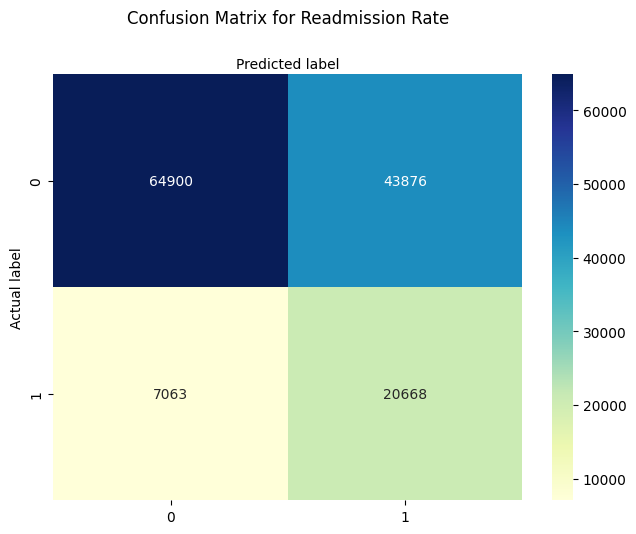

In [155]:
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion Matrix for Readmission Rate', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')


In [108]:
target_names = ['not readmission', 'readmission']
print(classification_report(y_test, y_pred, target_names=target_names))

                 precision    recall  f1-score   support

not readmission       0.90      0.60      0.72    108776
    readmission       0.32      0.75      0.45     27731

       accuracy                           0.63    136507
      macro avg       0.61      0.67      0.58    136507
   weighted avg       0.78      0.63      0.66    136507



In [57]:
sensitivity = metrics.recall_score(y_test, y_pred)
specificity = metrics.recall_score(np.logical_not(y_test), np.logical_not(y_pred))
print("Sensitivity =",round(sensitivity,2)) #  TP / (TP + FN) - Ideally want less FN
print("Specificity =",round(specificity,2)) # TN / (TN + FP)

Sensitivity = 0.75
Specificity = 0.6


c:\Users\smahmood\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


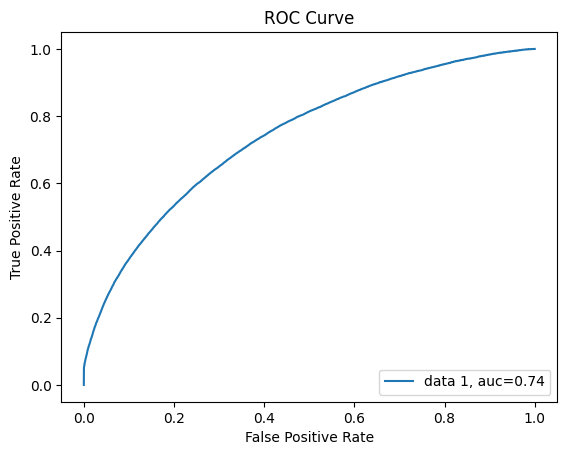

In [157]:
y_pred_proba = logreg.predict_proba(X_test)[::,1] # gets confidence level for each prediction
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_proba)
auc = metrics.roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr,tpr,label="data 1, auc="+str(round(auc,2)))
plt.legend(loc=4)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

In [117]:
coef = logreg.coef_[0]  # For binary classification
feature_names = X_train.columns  

In [118]:
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef,
    'Odds Ratio': np.exp(coef),
    'Diagnosis Name': "",
    'Procedure Name': "",
    "Medication Name": ""
})

In [119]:
# Prepare lookup tables
diagnosis_lookup = df_admit_diagnosis['diagnosis_converted'].unique()
proc_lookup = df_admit_diagnosis['procedure_converted'].unique()
diagnosis_lookup = diagnosis_lookup[diagnosis_lookup != 'Other Diagnosis']
proc_lookup = proc_lookup[proc_lookup != 'Other Procedure']
medication_lookup = df_medi['medication_grouped'].unique()  

# Loop through each row
for idx, row in coef_df.iterrows():
    feature = row['Feature']

    if feature in diagnosis_lookup:
        coef_df.at[idx, 'Diagnosis Name'] = feature
    
    if feature in proc_lookup:
        coef_df.at[idx, 'Procedure Name'] = feature

    # If it's a medication, keep the name
    if feature in medication_lookup:
        coef_df.at[idx, 'Medication Name'] = feature



In [198]:
coef_df_diagnosis = coef_df[['Feature','Coefficient','Odds Ratio','Diagnosis Name']].sort_values(by=['Odds Ratio','Diagnosis Name'], ascending=False)
coef_df_diagnosis = coef_df_diagnosis[coef_df_diagnosis['Diagnosis Name'].notna() & (coef_df_diagnosis['Diagnosis Name'] != '')]
pd.set_option('max_colwidth', 400)
coef_df_diagnosis.head(10)

,Feature,Coefficient,Odds Ratio,Diagnosis Name
77,acidosis,-0.192221,0.825125,acidosis
130,corridor hospital place occurrence external,-0.199213,0.819376,corridor hospital place occurrence external
146,dizziness giddiness,-0.203762,0.815656,dizziness giddiness
223,patient bathroom hospital place occurrence external,-0.231141,0.793627,patient bathroom hospital place occurrence external
84,acute kidney failure tubular necrosis,-0.242620,0.784569,acute kidney failure tubular necrosis
256,syncope collapse,-0.270117,0.763290,syncope collapse
86,acute respiratory failure,-0.399750,0.670488,acute respiratory failure
181,immunization,-0.627371,0.533994,immunization
251,single live birth,-1.059654,0.346576,single live birth
203,motorcycle driver injured collision fixed stationary object nontraffic accident,-1.571323,0.207770,motorcycle driver injured collision fixed stationary object nontraffic accident


In [175]:
coef_df_proc = coef_df[['Feature','Coefficient','Odds Ratio','Procedure Name']].sort_values(by=['Odds Ratio','Procedure Name'], ascending=False)
coef_df_proc = coef_df_proc[coef_df_proc['Procedure Name'].notna() & (coef_df_proc['Procedure Name'] != '')]
coef_df_proc.head(10)

,Feature,Coefficient,Odds Ratio,Procedure Name
405,operations bladder,0.915490,2.497999,operations bladder
375,laparoscopic repair hernia abdominal wall graft prosthesis,0.794714,2.213808,laparoscopic repair hernia abdominal wall graft prosthesis
427,reconstructive refractive surgery cornea,0.764841,2.148653,reconstructive refractive surgery cornea
426,radical cystectomy,0.646286,1.908439,radical cystectomy
295,biopsy cornea,0.608096,1.836931,biopsy cornea
374,laparoscopic incisional hernia repair graft prosthesis,0.599691,1.821557,laparoscopic incisional hernia repair graft prosthesis
410,osteoclasis patella,0.580825,1.787513,osteoclasis patella
372,keratoprosthesis,0.491152,1.634197,keratoprosthesis
463,therapeutic leukopheresis,0.487724,1.628605,therapeutic leukopheresis
358,incision excision congenital septum uterus,0.462303,1.587727,incision excision congenital septum uterus


In [176]:
coef_df_medi = coef_df[['Feature','Coefficient','Odds Ratio','Medication Name']].sort_values(by=['Odds Ratio','Medication Name'], ascending=False)
coef_df_medi = coef_df_medi[coef_df_medi['Medication Name'].notna() & (coef_df_medi['Medication Name'] != '')]
coef_df_medi.head(10)

,Feature,Coefficient,Odds Ratio,Medication Name
673,vancomycin oral liquid,0.587203,1.798950,vancomycin oral liquid
649,rifaximin,0.561168,1.752718,rifaximin
501,atovaquone suspension,0.507465,1.661074,atovaquone suspension
662,sulfameth/trimethoprim ss,0.381287,1.464168,sulfameth/trimethoprim ss
597,meropenem,0.325075,1.384135,meropenem
552,fluconazole,0.294161,1.342000,fluconazole
671,ursodiol,0.290487,1.337079,ursodiol
658,sodium chloride,0.287452,1.333026,sodium chloride
601,metoclopramide,0.276889,1.319020,metoclopramide
517,cefepime,0.268456,1.307943,cefepime


In [177]:
coef_df_medi_admit_location = coef_df[coef_df['Feature'].str.contains('admission_location')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_admit_location

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
14,admission_location_INTERNAL TRANSFER TO OR FROM PSYCH,5.072105,159.509683,,,
19,admission_location_TRANSFER FROM SKILLED NURSING FACILITY,0.962994,2.619527,,,
11,admission_location_CLINIC REFERRAL,-0.098786,0.905936,,,
20,admission_location_WALK-IN/SELF REFERRAL,-0.204975,0.814668,,,
12,admission_location_EMERGENCY ROOM,-0.223777,0.799493,,,
16,admission_location_PHYSICIAN REFERRAL,-0.225510,0.798109,,,
17,admission_location_PROCEDURE SITE,-0.347513,0.706443,,,
15,admission_location_PACU,-0.415299,0.660143,,,
13,admission_location_INFORMATION NOT AVAILABLE,-0.449645,0.637854,,,
18,admission_location_TRANSFER FROM HOSPITAL,-0.812450,0.443769,,,


In [178]:
coef_df_medi_admit_type = coef_df[coef_df['Feature'].str.contains('admission_type')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_admit_type

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
3,admission_type_DIRECT EMER.,1.128905,3.092270,,,
5,admission_type_ELECTIVE,0.438479,1.550347,,,
8,admission_type_OBSERVATION ADMIT,0.277051,1.319233,,,
7,admission_type_EW EMER.,0.233875,1.263486,,,
4,admission_type_DIRECT OBSERVATION,0.216945,1.242276,,,
10,admission_type_URGENT,0.086818,1.090698,,,
6,admission_type_EU OBSERVATION,0.066002,1.068228,,,
9,admission_type_SURGICAL SAME DAY ADMISSION,-0.383393,0.681545,,,


In [179]:
coef_df_medi_discharge_location = coef_df[coef_df['Feature'].str.contains('discharge_location')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_discharge_location

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
23,discharge_location_CHRONIC/LONG TERM ACUTE CARE,0.683101,1.980009,,,
28,discharge_location_HOSPICE,0.556634,1.744790,,,
24,discharge_location_DIED,0.526646,1.693243,,,
27,discharge_location_HOME HEALTH CARE,0.397529,1.488143,,,
21,discharge_location_AGAINST ADVICE,0.386973,1.472517,,,
31,discharge_location_REHAB,0.334113,1.396701,,,
32,discharge_location_SKILLED NURSING FACILITY,0.318957,1.375693,,,
22,discharge_location_ASSISTED LIVING,0.165375,1.179835,,,
29,discharge_location_OTHER FACILITY,0.027311,1.027688,,,
25,discharge_location_HEALTHCARE FACILITY,-0.025184,0.975130,,,


In [180]:
coef_df_medi_insurance = coef_df[coef_df['Feature'].str.contains('insurance')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_insurance

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
34,insurance_No charge,-0.025102,0.975211,,,
35,insurance_Other,-0.083628,0.919773,,,
33,insurance_Medicare,-0.130749,0.877438,,,
36,insurance_Private,-0.289129,0.748915,,,


In [181]:
coef_df_medi_race = coef_df[coef_df['Feature'].str.contains('race_')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_race

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
61,race_SOUTH AMERICAN,0.235995,1.266168,,,
60,race_PORTUGUESE,0.226032,1.253615,,,
66,race_WHITE - EASTERN EUROPEAN,0.171434,1.187005,,,
38,race_ASIAN - ASIAN INDIAN,0.168807,1.183891,,,
43,race_BLACK/AFRICAN AMERICAN,0.142624,1.153296,,,
42,race_BLACK/AFRICAN,0.097505,1.102417,,,
65,race_WHITE - BRAZILIAN,0.089957,1.094128,,,
52,race_HISPANIC/LATINO - HONDURAN,0.084634,1.088319,,,
54,race_HISPANIC/LATINO - PUERTO RICAN,0.063949,1.066038,,,
49,race_HISPANIC/LATINO - CUBAN,0.057868,1.059576,,,


In [182]:
coef_df_medi_marital = coef_df[coef_df['Feature'].str.contains('marital_status')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_marital

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
70,marital_status_SINGLE,0.045174,1.046210,,,
71,marital_status_WIDOWED,0.024799,1.025109,,,
69,marital_status_MARRIED,0.023714,1.023997,,,


In [183]:
coef_df_medi_age = coef_df[coef_df['Feature'].str.contains('anchor_age')].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_age

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
2,anchor_age,-0.004116,0.995893,,,


In [184]:
coef_df_medi_gender = coef_df[coef_df['Feature'].isin(['M', 'F'])].sort_values(by='Odds Ratio', ascending=False)
coef_df_medi_gender

,Feature,Coefficient,Odds Ratio,Diagnosis Name,Procedure Name,Medication Name
477,M,-0.086794,0.916866,,,
476,F,-0.223671,0.799578,,,


In [194]:
# Select top/bottom features by odds ratio
top_diagnosis_features = pd.concat([
    coef_df_diagnosis.sort_values(by='Odds Ratio').head(20),
    coef_df_diagnosis.sort_values(by='Odds Ratio').tail(20)
])

top_proc_features = pd.concat([
    coef_df_proc.sort_values(by='Odds Ratio').head(20),
    coef_df_proc.sort_values(by='Odds Ratio').tail(20)
])

top_medi_features = pd.concat([
    coef_df_medi.sort_values(by='Odds Ratio').head(20),
    coef_df_medi.sort_values(by='Odds Ratio').tail(20)
])

patient_features = pd.concat([
coef_df_medi_gender,coef_df_medi_age, coef_df_medi_insurance, coef_df_medi_marital, coef_df_medi_race
])
admission_features = pd.concat([coef_df_medi_admit_location, coef_df_medi_admit_type, coef_df_medi_discharge_location])
admission_features['Odds Ratio'] = admission_features['Odds Ratio'].clip(upper=5)


C:\Users\smahmood\AppData\Local\Temp\ipykernel_20320\2198469264.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Note: admission_location_INTERNAL TRANSFER TO OR FROM PSYCH contains an Odds Ratio over 150', fontsize=10, title_fontsize=7)


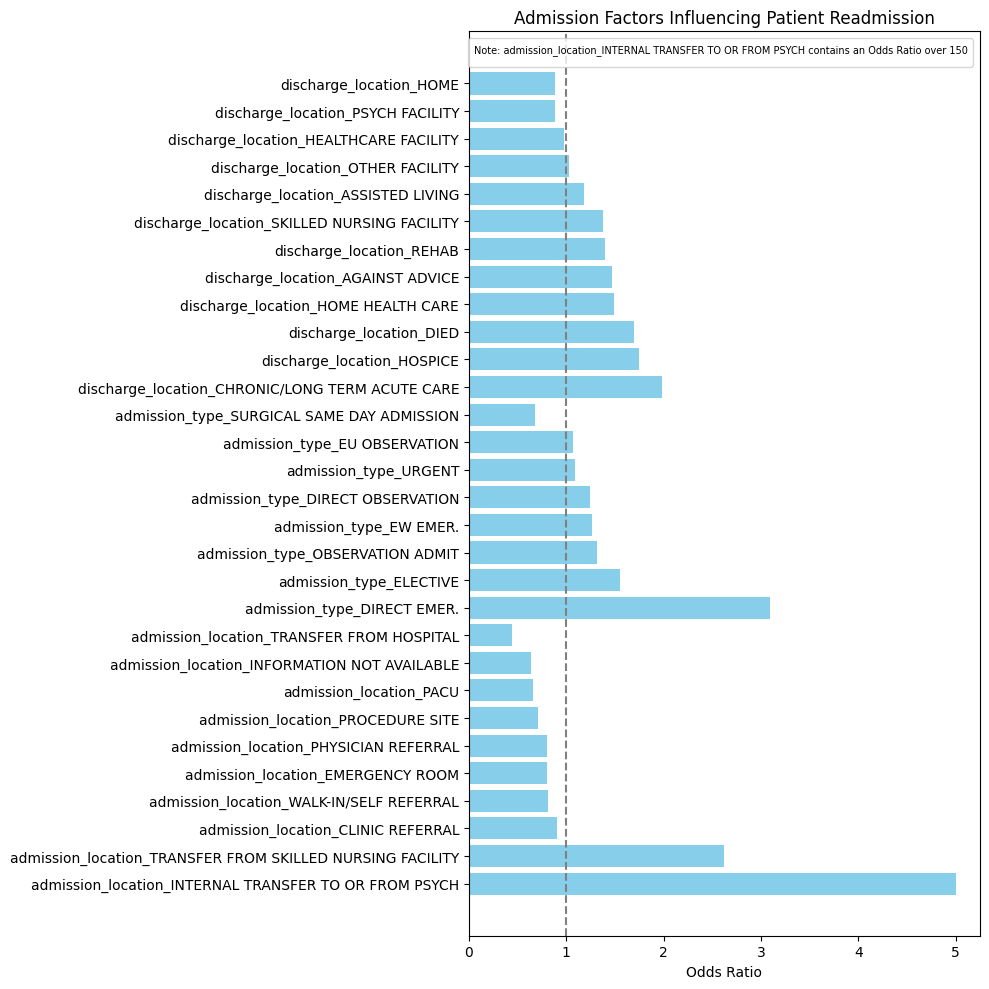

In [207]:
plt.figure(figsize=(10, 10))
plt.barh(
    y=admission_features['Feature'],
    width=admission_features['Odds Ratio'],
    color='skyblue'
)
plt.axvline(x=1, color='gray', linestyle='--')
plt.xlabel('Odds Ratio')
plt.yticks(fontsize=10)
plt.title('Admission Factors Influencing Patient Readmission')
plt.legend(title='Note: admission_location_INTERNAL TRANSFER TO OR FROM PSYCH contains an Odds Ratio over 150', fontsize=10, title_fontsize=7)
plt.tight_layout()
plt.show()
